DEBUG:geoquant.data_io:+++fetch_csv : EMIM.LSE, config/data_params:
DEBUG:geoquant.data_io:EMIM.UK - using cached data (no refresh)
INFO:geoquant.data_io:changes: []
INFO:geoquant.data_io:  EMIM.UK - no spikes detected in cached data


Downloaded shape: (2109, 5)
              Open    High     Low   Close   Volume
Date                                               
2018-01-02  2281.5  2281.5  2249.0  2253.0  2318701
              Open    High      Low   Close  Volume
Date                                               
2026-05-08  4040.0  4072.0  4020.44  4065.0  327475


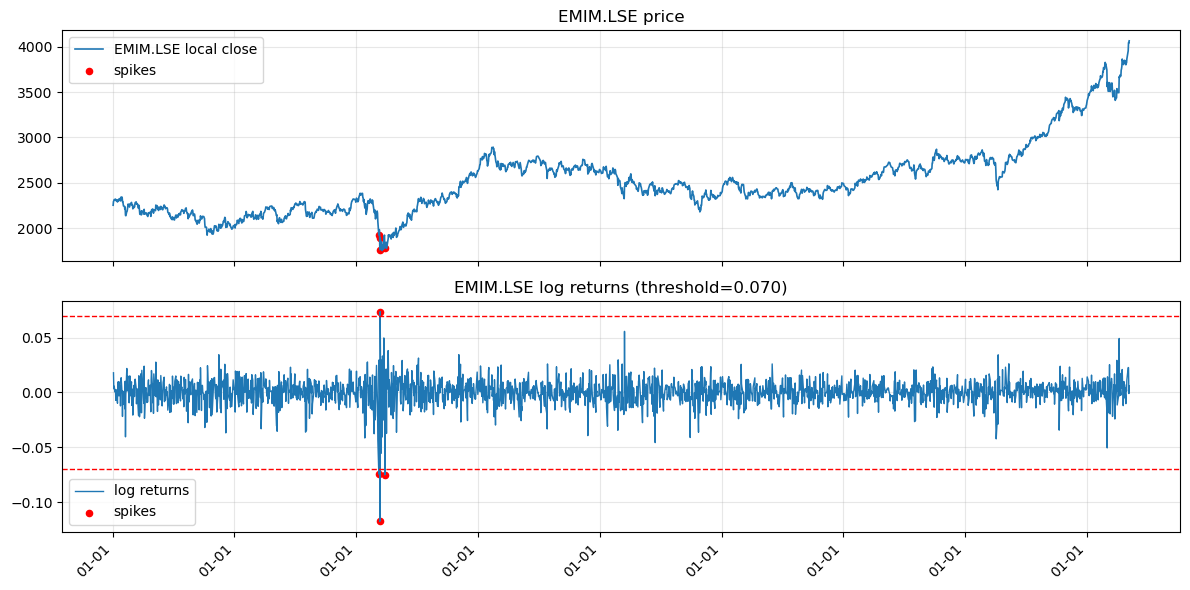

(<Figure size 1200x600 with 2 Axes>,
 array([<Axes: title={'center': 'EMIM.LSE price'}>,
        <Axes: title={'center': 'EMIM.LSE log returns (threshold=0.070)'}>],
       dtype=object),
 Date
 2020-03-12   -0.117278
 2020-03-27   -0.075008
 2020-03-09   -0.074275
 2020-03-13    0.073561
 Name: Close, dtype: float64)

In [8]:
# Test single ticker download from stooq (FX: GBPCHF)
import logging
from geoquant.data_io import fetch_csv
from geoquant.configs import config
from geoquant.plotting import plot_spike_inspection

logging.getLogger().setLevel(logging.DEBUG)

test_ticker = 'EMIM.LSE'
test_params = config.data_params.copy()
# test_params['max_age'] = 0  # force download

df_test = fetch_csv(test_ticker, data_params=test_params)
print('Downloaded shape:', df_test.shape)
print(df_test.head(1))
print(df_test.tail(1))
plot_spike_inspection(series=df_test, name=test_ticker)

In [ ]:
def eod_search(quey: str, token: str):
    import requests, pandas as pd
    url = f"https://eodhd.com/api/search/{quey}?api_token={token}&fmt=json"
    r = requests.get(url, timeout=30); r.raise_for_status()
    hits = r.json()
    # Return a small table to pick from
    return pd.DataFrame([{
        "code": h.get("Code"),
        "exchange": h.get("Exchange"),
        "name": h.get("Name"),
        "currency": h.get("Currency"),
        "type": h.get("Type"),
        "startdate": h.get("StartDate"),
        # earliet date

    } for h in hits])

# Usage:
df = eod_search("litg", config.EOD_API)
# pick the line with the longest available history (often XETRA/LSE/SIX)
print(df)